# Notebook Objectives

This notebook loads the behavior data with the trial by trial neural values (computed by the code ```neural_value_RUN_all_sessions.py```).

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)

---
# Setup


In [1]:
from neural_value_helpers import *
from popy.config import COLORS

plt.rcParams.update({'font.size': 8})


---
# Section 1: Get data (load from file)


In [2]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
# remove 5% outliers from dV
#behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
behav_new = behav_new.dropna()

In [3]:
#count nans
behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,R_6,R_7,R_8,fb_sequence,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_2_3.5,V_t_p1_2_3.5,dV_2_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,0.0,0.0,0.0,2.0,-0.150551,0.204889,0.355440,-0.091075,-0.143671,-0.052596
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,1.0,0.0,0.0,1.0,0.204889,-0.059881,-0.264770,-0.143671,-0.052697,0.090974
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,0.0,1.0,0.0,0.0,-0.059881,-0.200961,-0.141080,-0.052697,0.034984,0.087680
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,0.0,0.0,1.0,4.0,-0.200961,-0.070287,0.130675,0.034984,-0.073381,-0.108365
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,1.0,0.0,0.0,2.0,-0.070287,-0.073770,-0.003484,-0.073381,0.074128,0.147510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,1.0,1.0,1.0,6.0,0.796248,0.689507,-0.106742,0.662329,-0.087382,-0.749711
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,1.0,1.0,1.0,3.0,0.689507,0.057016,-0.632490,-0.087382,0.428223,0.515605
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,0.0,1.0,1.0,5.0,0.057016,0.362536,0.305519,0.428223,0.242185,-0.186038
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,0.0,0.0,1.0,6.0,0.362536,0.786138,0.423602,0.242185,0.515087,0.272902


In [4]:
# normalize dV and V_t per monkey, session, subregion
for time_interval in [(-4, -2), (2, 3.5)]:
    behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'dV_{time_interval[0]}_{time_interval[1]}'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] - behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']

behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,R_6,R_7,R_8,fb_sequence,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_2_3.5,V_t_p1_2_3.5,dV_2_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,0.0,0.0,0.0,2.0,-0.769454,0.812984,1.582438,-0.665557,-1.041484,-0.375927
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,1.0,0.0,0.0,1.0,0.811088,-0.362970,-1.174057,-1.028095,-0.407838,0.620257
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,0.0,1.0,0.0,0.0,-0.366271,-0.989564,-0.623293,-0.401019,0.202865,0.603883
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,0.0,0.0,1.0,4.0,-0.993615,-0.409184,0.584431,0.203352,-0.551911,-0.755264
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,1.0,0.0,0.0,2.0,-0.412541,-0.424657,-0.012115,-0.543598,0.475513,1.019112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66350,po,200722,dLPFC,372,8,1,1.0,0.0,0.0,0.723918,...,1.0,1.0,1.0,6.0,1.174154,1.031969,-0.142184,1.634867,-0.256168,-1.891035
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,1.0,1.0,1.0,3.0,1.031827,0.190688,-0.841139,-0.254353,1.043113,1.297466
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,0.0,1.0,1.0,5.0,0.188484,0.597062,0.408579,1.044936,0.574314,-0.470622
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,0.0,0.0,1.0,6.0,0.595854,1.160500,0.564645,0.576134,1.262004,0.685870


---
# Section 2: Analysis of the neural value representation

## History in the subspace

### Short history

Using all available CPU cores for parallel processing


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   47.4s
[Parallel(n_jobs=-1)]: Done 214 out of 214 | elapsed:   55.7s finished


Analysis complete!
Spearman correlation (rho): 0.730, p-value: 3.1e-146
Spearman correlation (rho): 0.710, p-value: 1.0e-106
Spearman correlation (rho): 0.702, p-value: 7.0e-24


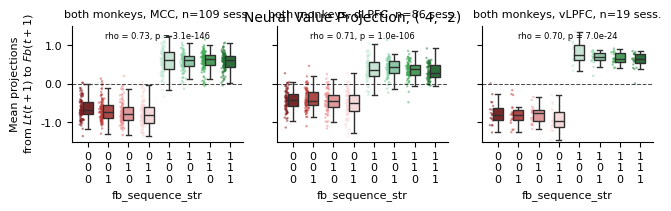

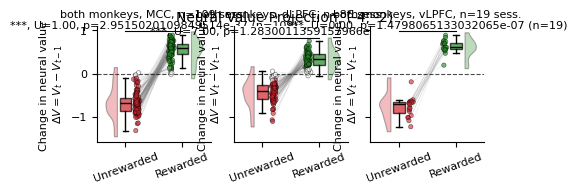

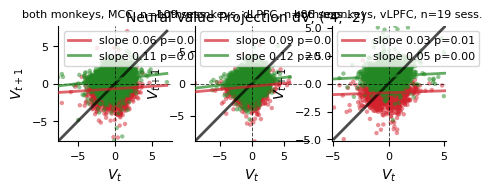

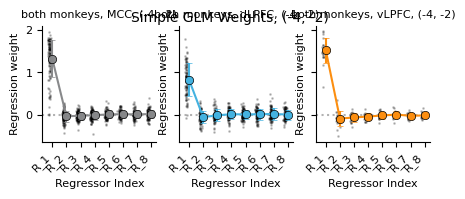

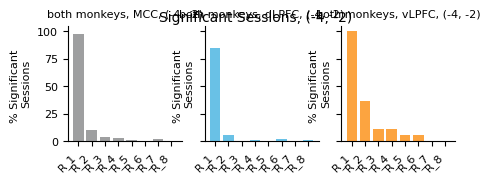

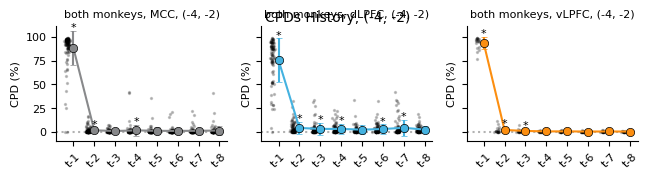

Using all available CPU cores for parallel processing


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   45.6s
[Parallel(n_jobs=-1)]: Done 214 out of 214 | elapsed:   54.9s finished


Analysis complete!
Spearman correlation (rho): 0.816, p-value: 2.0e-209
Spearman correlation (rho): 0.658, p-value: 1.7e-86
Spearman correlation (rho): 0.804, p-value: 1.1e-35


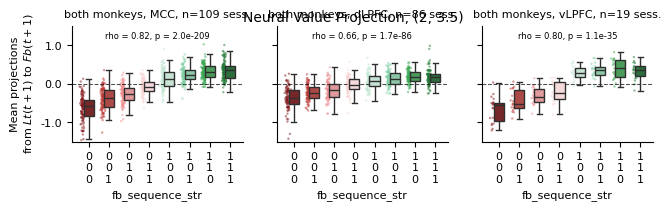

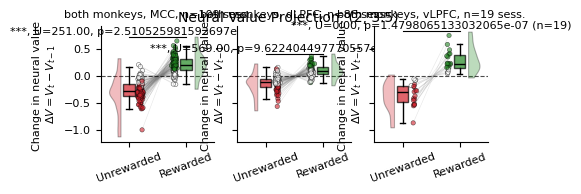

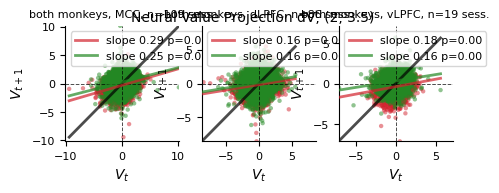

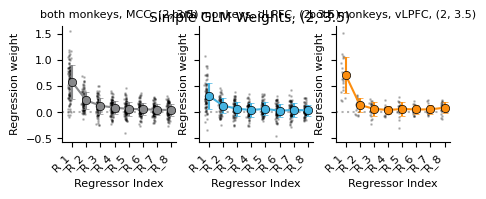

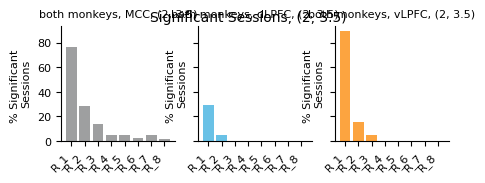

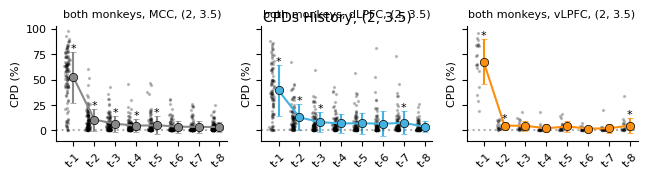

In [5]:
monkeys = 'both' # 'both', 'two'

n_perms = 1000  # number of permutations for CPD analysis

for time_interval in [(-4, -2), (2, 3.5)]:  
    # rename columns for plotting: V_T_... to V_t, dV_... to dV
    behav_new['V_t'] = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
    behav_new['V_t_p1'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}']
    behav_new['dV'] = behav_new[f'dV_{time_interval[0]}_{time_interval[1]}']

    # for each monkey, session, subregion, fb_sequence, take a mean of these columns
    behav_new_sess_avg_sequence = behav_new.copy().groupby(['monkey', 'session', 'subregion', 'fb_sequence'])['V_t'].mean().reset_index()

    behav_new_sess_avg_fb = []
    for (monkey, session, subregion), group in behav_new.groupby(['monkey', 'session', 'subregion']):
        U, pval = stats.mannwhitneyu(group.loc[group['feedback'] == 0, 'dV'], group.loc[group['feedback'] == 1, 'dV'], alternative='two-sided')
        for fb in group['feedback'].unique():
            behav_new_sess_avg_fb.append({
                'monkey': monkey,
                'session': session,
                'subregion': subregion,
                'feedback': fb,
                'V_t': group.loc[group['feedback'] == fb, 'V_t'].mean(),
                'V_t_p1': group.loc[group['feedback'] == fb, 'V_t_p1'].mean(),
                'dV': group.loc[group['feedback'] == fb, 'dV'].mean(),
                'U': U,
                'signif': pval < 0.05
            })
    behav_new_sess_avg_fb = pd.DataFrame(behav_new_sess_avg_fb)
        

    # calculate simple GLM weights for each session, subregion, monkey
    weights_all = simple_glm_weights(behav_new)

    # Main analysis with joblib parallelization
    cpd_all = get_cpd_all(behav_new, n_perms)

    # Plotting
    if monkeys == 'two':
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(2, 3, figsize=(8, 5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig4, axs4 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)

        for m, monkey in enumerate(behav_new['monkey'].unique()):
            for s, subregion in enumerate(behav_new['subregion'].unique()):
                # filter data for the current monkey and subregion
                behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[(behav_new_sess_avg_sequence['monkey'] == monkey) & (behav_new_sess_avg_sequence['subregion'] == subregion)]
                behav_new_sess_avg_fb_temp = behav_new_sess_avg_fb.loc[(behav_new_sess_avg_fb['monkey'] == monkey) & (behav_new_sess_avg_fb['subregion'] == subregion)]

                weights_all_temp = weights_all.loc[(weights_all['monkey'] == monkey) & (weights_all['subregion'] == subregion)]
                cpd_all_temp = cpd_all.loc[(cpd_all['monkey'] == monkey) & (cpd_all['subregion'] == subregion)]
                null_temp = create_permutation_null(behav_new.loc[(behav_new['monkey'] == monkey) & (behav_new['subregion'] == subregion)], n_perms=n_perms)

                ax = axs1[m, s]
                plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=False, ylim=None, show_datapoints=True, showfliers=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs2[m, s]
                plot_dV_per_fb(behav_new_sess_avg_fb_temp, paper_format=False, ylim=None, show_datapoints=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs3[m, s]
                green_red_plot(behav_new_sess_avg_fb_temp, paper_format=False, ylim=None, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs4[m, s]
                plot_simple_glm_weights(weights_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs5[m, s]
                plot_prop_signif_sessions(cpd_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs6[m, s]
                plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)


        # save figure
        #fig.savefig(f'figs/all_sess_neural_value_projection.svg', bbox_inches='tight', transparent=True)

    else:
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(1, 3, figsize=(5, 1.5)) 
        fig4, axs4 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig6, axs6 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)

        monkey = 'both monkeys'

        for s, subregion in enumerate(behav_new['subregion'].unique()):
            behav_new_temp = behav_new.loc[behav_new['subregion'] == subregion]
            behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[behav_new_sess_avg_sequence['subregion'] == subregion]
            behav_new_sess_avg_feed_temp = behav_new_sess_avg_fb.loc[behav_new_sess_avg_fb['subregion'] == subregion]

            weights_all_temp = weights_all.loc[weights_all['subregion'] == subregion]
            cpd_all_temp = cpd_all.loc[cpd_all['subregion'] == subregion]
            null_temp = create_permutation_null(behav_new.loc[behav_new['subregion'] == subregion], n_perms=n_perms)

            ax = axs1[s]
            plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=True, ylim=[-1.5, 1.5], show_datapoints=True, showfliers=False, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_sequence_temp["session"].unique())} sess.', fontsize=8)

            ax = axs2[s]
            create_r_style_plot(ax, behav_new_sess_avg_feed_temp, 'feedback', 'dV')
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_feed_temp["session"].unique())} sess.', fontsize=8)

            ax = axs3[s]
            green_red_plot(behav_new_temp.dropna(), paper_format=True, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_temp["session"].unique())} sess.', fontsize=8)

            ax = axs4[s]
            plot_simple_glm_weights(weights_all_temp, ax=ax, show_data=False)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs5[s]
            plot_prop_signif_sessions(cpd_all_temp, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs6[s]
            plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=True)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

        # save figure
        fig1.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig2.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig3.suptitle(f'Neural Value Projection dV, {time_interval}', fontsize=10)
        fig4.suptitle(f'Simple GLM Weights, {time_interval}', fontsize=10)
        fig5.suptitle(f'Significant Sessions, {time_interval}', fontsize=10)
        fig6.suptitle(f'CPDs History, {time_interval}', fontsize=10)


        fig1.savefig(f'figs/neural_value/all_sess_neural_value_projection_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig2.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig3.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_fb_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig4.savefig(f'figs/neural_value/simple_glm_weights_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig5.savefig(f'figs/neural_value/sig_sessions_cpd_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)
        fig6.savefig(f'figs/neural_value/cpds_history_neural_value_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)

        plt.show()
        plt.close('all')


# decodability

In [6]:
# open fike

from popy.config import PROJECT_PATH_LOCAL as PATH

floc = os.path.join(PATH, 'notebooks/population_decoding/results/neural_values_across_time/across_time_decodability_matrix.nc')
decodability_matrix = xr.open_dataarray(floc)
floc = os.path.join(PATH, 'notebooks/population_decoding/results/neural_values_across_time/trajectories.nc')
trajectories = xr.open_dataarray(floc)

In [7]:
def value_sessions(trajectories):
    t_interest = (-1, 1)  # time interval of interest for value sessions
    value_sessions = []

    for session in trajectories.session.values:
        values = trajectories.sel(session=session, time=slice(*t_interest)).mean(dim='time')  # 8 points for 8 trajectories or neural values
        # if monotonic increasing (pearsonr)
        values_negative = values.sel(fb_sequence=slice(0, 3))  # only the first 4 fb sequences
        # if monotonic increase:
        if np.all(np.diff(values_negative.values) >= 0):
            value_sessions.append(session)

    print(f'Value sessions: {len(value_sessions)} out of {len(trajectories.session.values)}')
    return trajectories.sel(session=value_sessions)



NameError: name 'sample_colors' is not defined

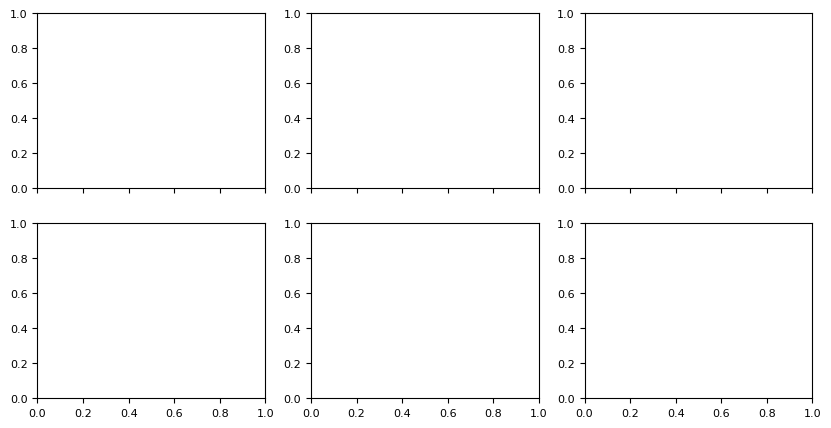

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True)
colors = sample_colors(8)
time_interval = (-5, 5)

# where the session field ends with MCC
for m, monkey in enumerate(["ka", "po"]):
    for s, subregion in enumerate(['MCC', 'dLPFC', 'vLPFC']):
        ax = axs[m, s]

        trajectories_temp = trajectories.sel(session=(trajectories.session.str.endswith(subregion)) & (trajectories.session.str.startswith(monkey)))
        #trajectories_temp = value_sessions(trajectories_temp)
        trajectories_temp = trajectories_temp.sel(time=slice(*time_interval))

        if len(trajectories_temp) == 0:
            print(f'No value sessions for {monkey} {subregion}')
            continue
        for fb_seq in np.unique(trajectories.fb_sequence.values):
            data = trajectories_temp.sel(fb_sequence=fb_seq).mean(dim='session').values
            data_smooth = np.convolve(data, np.ones(5)/5, mode='same')

            ax.plot(trajectories_temp.time, data_smooth, label=f'{monkey} {subregion} {fb_seq}', color=colors[int(fb_seq)])

            plot_keypoints(ax, (-1, 0), mark_event='Fb')
            ax.grid(axis='x', linestyle='--', alpha=0.5)

        ax.set_title(f'{monkey} {subregion}, n={len(trajectories_temp)}')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlim(time_interval)


# save figure
fig.suptitle(f'Neural Value Projection, all sess. avg.', fontsize=10)
fig.savefig(f'figs/neural_value/all_sessions_projection.svg', bbox_inches='tight', transparent=True)

In [ ]:
decodability_matrix

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
cmap = plt.get_cmap('RdBu')
time_interval = (-5, 5)

# where the session field ends with MCC
for m, monkey in enumerate(["ka", "po"]):
    for s, subregion in enumerate(['MCC', 'dLPFC', 'vLPFC']):
        ax = axs[m, s]

        matrix_temp = decodability_matrix.sel(session=(decodability_matrix.session.str.endswith(subregion)) & (decodability_matrix.session.str.startswith(monkey)))
        matrix_temp = matrix_temp.sel(train_time=slice(*time_interval), test_time=slice(*time_interval))
        matrix_temp = matrix_temp.mean(dim='session').values

        #ax.plot(matrix_temp.time, data, label=f'{monkey} {subregion} {fb_seq}', color=cmap(fb_seq / len(np.unique(decodability_matrix.fb_sequence.values))))
        v_extreme = np.max(np.abs(matrix_temp))
        vmin = .5 - (v_extreme - .5)
        vmax = .5 + (v_extreme - .5)
        pbar = ax.imshow(matrix_temp, aspect='auto', cmap=cmap, extent=[time_interval[0], time_interval[1], time_interval[0], time_interval[1]], origin='lower', vmin=vmin, vmax=vmax)
        plt.colorbar(pbar, ax=ax)

        plot_keypoints(ax, (-1, 0), axis='both', mark_event='Fb')
        ax.grid(linestyle='--', alpha=0.5)

        ax.set_title(f'{monkey} {subregion}')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlim(time_interval)
        ax.set_ylim(time_interval)

# save figure
fig.suptitle(f'Neural Value Decodability Matrix, all sess. avg.', fontsize=10)
fig.savefig(f'figs/neural_value/all_sessions_decodability_matrix.svg', bbox_inches='tight', transparent=True)
